# Caso de Negocio

El caso de negocio consiste en desarrollar un modelo predictivo que permita estimar si un cliente de una empresa de telecomunicaciones abandonará el servicio (churn) a partir de información disponible sobre sus características y los servicios que utiliza. Para ello se utilizará un dataset que incluye variables relacionadas con el perfil del cliente, su antigüedad en la empresa, los servicios contratados y las condiciones de facturación y pago. El objetivo es entrenar un modelo de machine learning capaz de predecir la variable objetivo “Churn”, identificando a los clientes con mayor probabilidad de cancelar el servicio. Esta información puede ser utilizada por la empresa para implementar estrategias de retención de manera anticipada, reduciendo la pérdida de clientes y mejorando la gestión de la relación con los usuarios.

El dataset utilizado corresponde a un conjunto de datos de IBM Sample Data Sets, comúnmente empleado en problemas de predicción de churn en telecomunicaciones.

# Obtención y descripción de dataset

Link al kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Importamos todas las librerias necesarias para el TP1

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample
from itertools import combinations
from scipy.stats import f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from itertools import combinations
from scipy.stats import chi2_contingency

Leemos el csv para obtener el dataframe y comenzar el proyecto. Para no tener que cargar constantemente el codigo a los archivos o estar abriendo el drive lo traemos directo del repositorio de github.

In [66]:
path = "https://raw.githubusercontent.com/FelipeTamaki/Analisis-Predictivo-Telco-Churn/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [67]:
df_churn = pd.read_csv(path)
df_churn_backup = df_churn.copy()
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Pasamos todos los valores de las columnas a minúsculas para que esten todos de la misma forma.

In [68]:
df_churn.columns = df_churn.columns.str.lower()
df_churn.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Descripción del dataset

El dataset utilizado contiene información de clientes de una empresa de telecomunicaciones y tiene como objetivo analizar los factores asociados al abandono del servicio (churn).

Cada fila del dataset representa un cliente individual.

El objetivo del análisis es identificar patrones que permitan entender qué variables influyen en la probabilidad de que un cliente abandone el servicio y eventualmente desarrollar un modelo predictivo que permita anticipar ese comportamiento. Predecir si un cliente va "churnear".

En total, el dataset contiene **7043 clientes y 21 variables**.

Las variables pueden agruparse en cuatro grandes categorías:

1. Información del cliente
* género
* si es adulto mayor
* si tiene pareja
* si tiene dependientes

2. Información del servicio
* tipo de servicio telefónico
* servicio de internet
* servicios adicionales

3. Información contractual
* tipo de contrato
* método de pago
* facturación electrónica

4. Información económica
* cargo mensual
* cargos acumulados


## Dataset Dictionary

Diccionario de datos con la descripción de cada variable del dataset.

| Variable | Descripción | Valores posibles |
|--------|-------------|----------------|
| customerID | Identificador único del cliente | String |
| gender | Género del cliente | Male / Female |
| SeniorCitizen | Indica si el cliente es adulto mayor | 0 = No / 1 = Sí |
| Partner | Indica si el cliente tiene pareja | Yes / No |
| Dependents | Indica si el cliente tiene dependientes | Yes / No |
| tenure | Cantidad de meses que el cliente lleva en la empresa | Número entero |
| PhoneService | Indica si el cliente tiene servicio telefónico | Yes / No |
| MultipleLines | Indica si el cliente tiene múltiples líneas telefónicas | Yes / No / No phone service |
| InternetService | Tipo de servicio de internet contratado | DSL / Fiber optic / No |
| OnlineSecurity | Indica si el cliente tiene servicio de seguridad online | Yes / No / No internet service |
| OnlineBackup | Indica si el cliente tiene servicio de respaldo online | Yes / No / No internet service |
| DeviceProtection | Indica si el cliente tiene protección de dispositivos | Yes / No / No internet service |
| TechSupport | Indica si el cliente tiene soporte técnico | Yes / No / No internet service |
| StreamingTV | Indica si el cliente tiene servicio de TV por streaming | Yes / No / No internet service |
| StreamingMovies | Indica si el cliente tiene servicio de películas por streaming | Yes / No / No internet service |
| Contract | Tipo de contrato del cliente | Month-to-month / One year / Two year |
| PaperlessBilling | Indica si el cliente utiliza facturación electrónica | Yes / No |
| PaymentMethod | Método de pago del cliente | Electronic check / Mailed check / Bank transfer / Credit card |
| MonthlyCharges | Cargo mensual que paga el cliente | Número decimal |
| TotalCharges | Total pagado por el cliente desde que inició el servicio | Número decimal |
| Churn | Indica si el cliente abandonó el servicio | Yes / No |

# EDA

Revisamos la estructura del dataframe

In [69]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [70]:
df_churn.describe()

,seniorcitizen,tenure,monthlycharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [71]:
df_churn.shape

(7043, 21)

Verificamos la existencia de NAs, en este caso el dataset ya estaba limpio y nuestras variables no contienen Nas.

In [72]:
df_churn.isna().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


Verificamos la existencia de duplicados en el df_churn para decidir que hacer en caso de encontrarlos.

In [73]:
df_churn.duplicated().sum()

np.int64(0)

Nos dimos cuenta que la variable totalcharges en vez de tener valores 0 tenia espacios y no nos iba a servir para el análisis.

In [74]:
df_churn[df_churn["tenure"]==0].head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


Decidimos eliminar a los valores con tenure 0 porque no aportan valor y quitan eficiencia al modelo al funcionar como punto de leverage.

In [75]:
df_churn["totalcharges"] = pd.to_numeric(df_churn["totalcharges"], errors="coerce")

In [76]:
df_churn = df_churn[df_churn["tenure"]!=0]

Para comenzar con el análisis exploratorio primero evidenciamos la proporción de churn que nos muestra que hay aproximadamente un 26,5% de clientes que churnean. Este dato es muy importante porque es lo que aspiramos a disminuir al tener la capacidad de predecir cuando un cliente va a churnear.

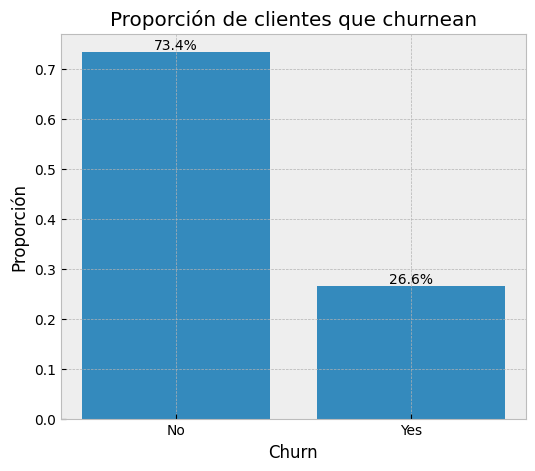

In [77]:
churn_prop = df_churn["churn"].value_counts(normalize=True)
plt.figure(figsize=(6,5))
bars = plt.bar(churn_prop.index, churn_prop.values)
plt.title("Proporción de clientes que churnean")
plt.xlabel("Churn")
plt.ylabel("Proporción")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.1%}", ha='center', va='bottom')

plt.show()

Los datos muestran que el churn es mucho más alto en clientes con contrato mes a mes, mientras que los contratos de uno o dos años casi no abandonan. También churnean más quienes pagan con electronic check, los que tienen fibra óptica y los que no tienen servicios extra como online security o tech support. En cambio, variables como género, phone service o multiple lines casi no muestran diferencias.

In [78]:
# Variables categóricas que quieres analizar contra churn
variables_categoricas = [
    "contract", "internetservice", "paymentmethod", "partner",
    "paperlessbilling", "seniorcitizen", "gender", "dependents",
    "phoneservice", "onlinesecurity", "multiplelines", "onlinebackup",
    "deviceprotection", "techsupport", "streamingtv", "streamingmovies"
]

target = "churn"
alpha = 0.05

df = df_churn.copy()

variables_significativas = []

for variable in variables_categoricas:
    print("\n" + "=" * 70)
    print(f"VARIABLE: {variable.upper()}")

    # 1) Tabla de conteos
    tabla_conteos = pd.crosstab(df[variable], df[target])
    print("\nTabla de conteos:")
    print(tabla_conteos)

    # 2) Tabla de proporciones por categoría
    tabla_proporciones = pd.crosstab(
        df[variable],
        df[target],
        normalize="index"
    ).round(3)

    print("\nProporción de churn dentro de cada categoría:")
    print(tabla_proporciones)

    # Validación mínima para poder correr chi-cuadrado
    if tabla_conteos.shape[0] < 2 or tabla_conteos.shape[1] < 2:
        print("\nNo se puede aplicar chi-cuadrado a esta variable.")
        continue

    # 3) Test global chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla_conteos)

    print("\nTest global chi-cuadrado")
    print(f"Chi2 = {chi2:.4f}")
    print(f"Grados de libertad = {dof}")
    print(f"p-value = {p_value:.6g}")

    if p_value >= alpha:
        print("Conclusión: no hay evidencia suficiente de asociación con churn.")
        continue

    print("Conclusión: sí hay asociación con churn.")
    variables_significativas.append(variable)

    # 4) Comparaciones por pares entre categorías
    categorias = df[variable].dropna().unique()
    print("\nComparaciones por pares:")

    for cat1, cat2 in combinations(categorias, 2):
        sub_df = df[df[variable].isin([cat1, cat2])]
        tabla_par = pd.crosstab(sub_df[variable], sub_df[target])

        # Necesitamos una tabla 2x2
        if tabla_par.shape != (2, 2):
            print(f"{cat1} vs {cat2} -> no se puede evaluar")
            continue

        chi2_par, p_par, dof_par, expected_par = chi2_contingency(tabla_par)

        prop_cat1 = (sub_df[sub_df[variable] == cat1][target] == "Yes").mean()
        prop_cat2 = (sub_df[sub_df[variable] == cat2][target] == "Yes").mean()
        diff = prop_cat1 - prop_cat2

        print(
            f"{cat1} vs {cat2} | "
            f"p-value = {p_par:.6g} | "
            f"prop_churn = {prop_cat1:.3f} vs {prop_cat2:.3f} | "
            f"diferencia = {diff:.3f}"
        )

print("\n" + "=" * 70)
print("Variables con asociación significativa con churn:")
print(variables_significativas)


VARIABLE: CONTRACT

Tabla de conteos:
churn             No   Yes
contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48

Proporción de churn dentro de cada categoría:
churn              No    Yes
contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028

Test global chi-cuadrado
Chi2 = 1179.5458
Grados de libertad = 2
p-value = 7.32618e-257
Conclusión: sí hay asociación con churn.

Comparaciones por pares:
Month-to-month vs One year | p-value = 9.14738e-104 | prop_churn = 0.427 vs 0.113 | diferencia = 0.314
Month-to-month vs Two year | p-value = 1.39637e-192 | prop_churn = 0.427 vs 0.028 | diferencia = 0.399
One year vs Two year | p-value = 1.08772e-20 | prop_churn = 0.113 vs 0.028 | diferencia = 0.084

VARIABLE: INTERNETSERVICE

Tabla de conteos:
churn              No   Yes
internetservice            
DSL              1957   459
Fiber optic      1799  1297
No               1

Los gráficos confirman lo mismo que se veía en los números: el churn es mucho más alto en contratos mes a mes, mientras que casi desaparece en contratos largos. También es más alto en clientes con fibra óptica, en quienes pagan con electronic check y en los que usan paperless billing. Además, los senior citizens y los clientes sin tech support muestran una mayor proporción de abandono. A continuación mostramos lo mismo de forma gráfica para algunas de las variables que creemos tendrán mayor valor a la hora de predecir el churn.

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)
/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)
/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)
/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)
/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: User

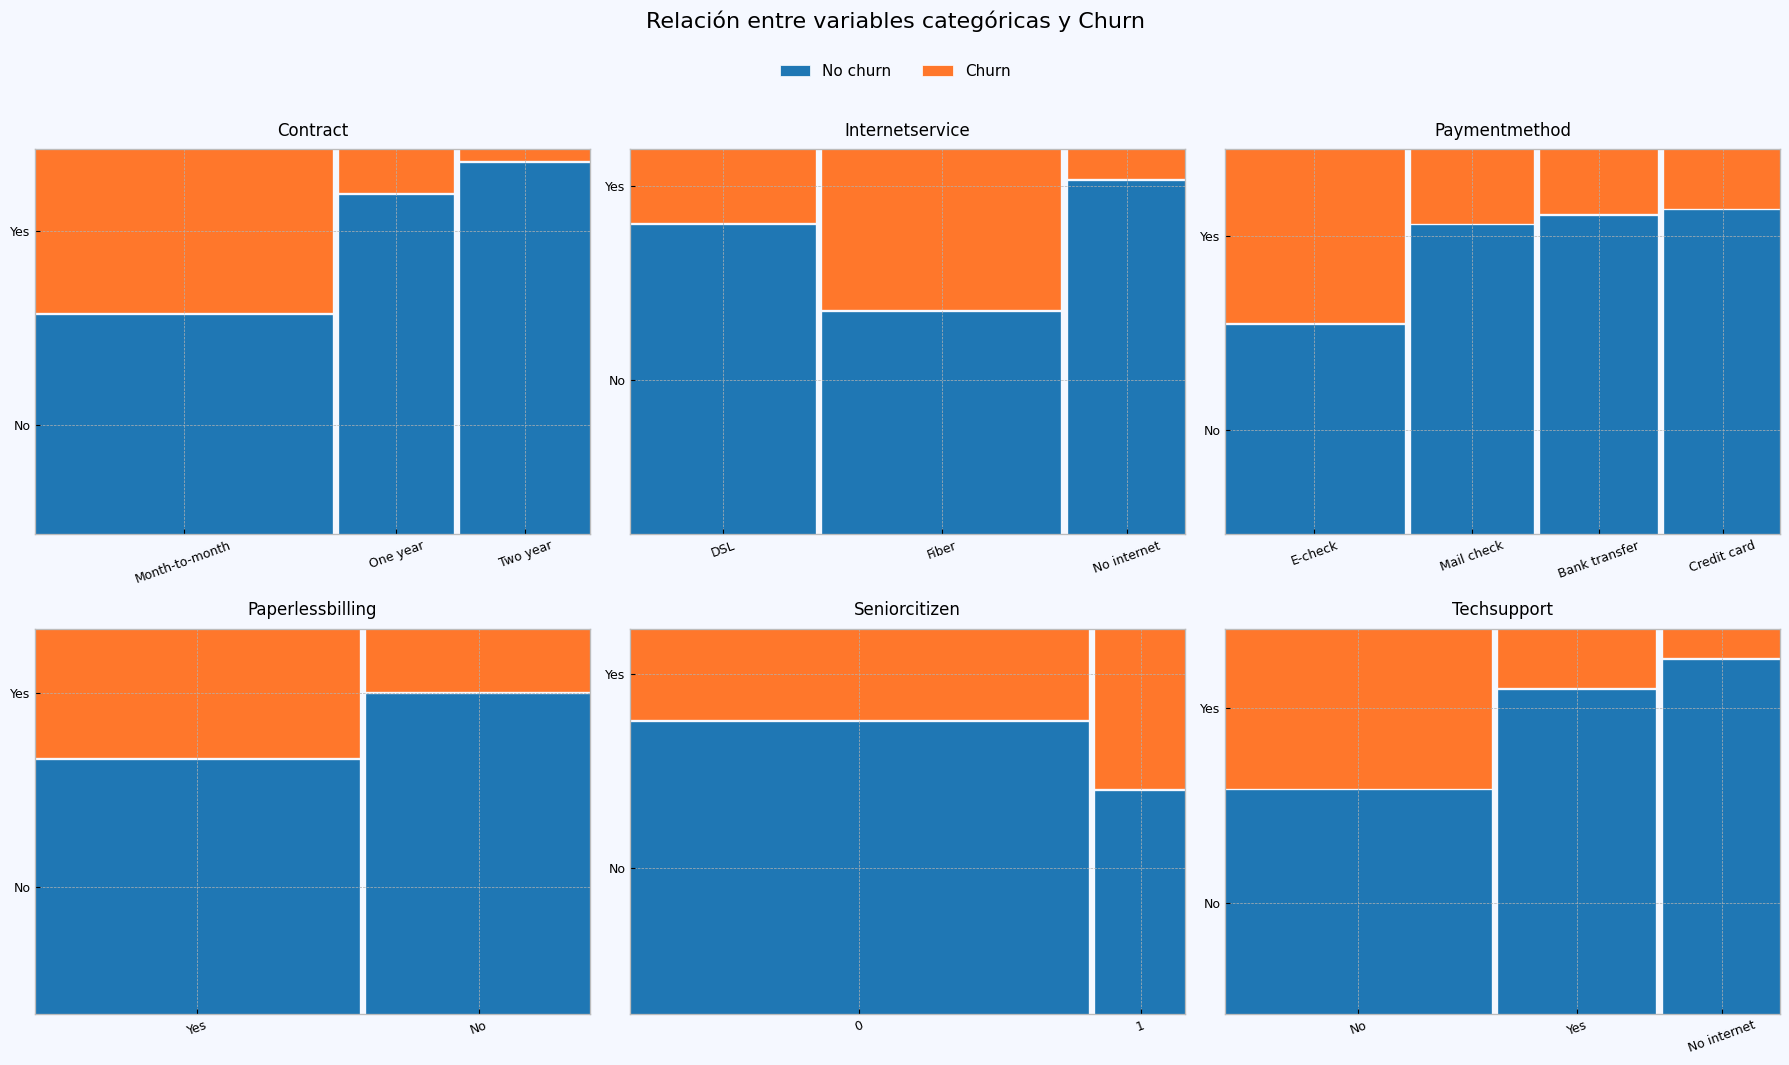

In [79]:
bg_color = "#f5f8ff"

cols = [
    "contract", "internetservice", "paymentmethod",
    "paperlessbilling", "seniorcitizen", "techsupport"
]

# Copia para acortar nombres largos en algunos campos
df_plot = df_churn.copy()

df_plot["paymentmethod"] = df_plot["paymentmethod"].replace({
    "Electronic check": "E-check",
    "Mailed check": "Mail check",
    "Bank transfer (automatic)": "Bank transfer",
    "Credit card (automatic)": "Credit card"
})

df_plot["internetservice"] = df_plot["internetservice"].replace({
    "Fiber optic": "Fiber",
    "No": "No internet"
})

df_plot["techsupport"] = df_plot["techsupport"].replace({
    "No internet service": "No internet"
})

# Paleta
color_no = "#1f77b4"
color_yes = "#ff772b"

def props(key):
    return {
        "color": color_no if key[1] == "No" else color_yes,
        "edgecolor": "white",
        "linewidth": 1.2
    }

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=bg_color)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.set_facecolor(bg_color)

    mosaic(
        df_plot,
        [col, "churn"],
        ax=ax,
        properties=props,
        labelizer=lambda key: "",
        gap=0.015,
        axes_label=True
    )

    ax.set_title(col.replace("_", " ").title(), fontsize=12, pad=10)

    # Limpieza visual
    ax.tick_params(axis="x", labelrotation=20, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

# Leyenda general
legend_elements = [
    Patch(facecolor=color_no, edgecolor="white", label="No churn"),
    Patch(facecolor=color_yes, edgecolor="white", label="Churn")
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=11
)

fig.suptitle("Relación entre variables categóricas y Churn", fontsize=16, y=1.06)

plt.tight_layout()
plt.show()

Acá se ve que el churn ocurre sobre todo en clientes con poca antigüedad: la mayoría de los que se van están en los primeros meses, mientras que los clientes con muchos años casi no abandonan. También se nota que quienes churnean tienden a tener monthly charges más altos, y que los clientes que se quedan acumulan total charges mucho mayores, lo que tiene sentido porque llevan más tiempo usando el servicio.

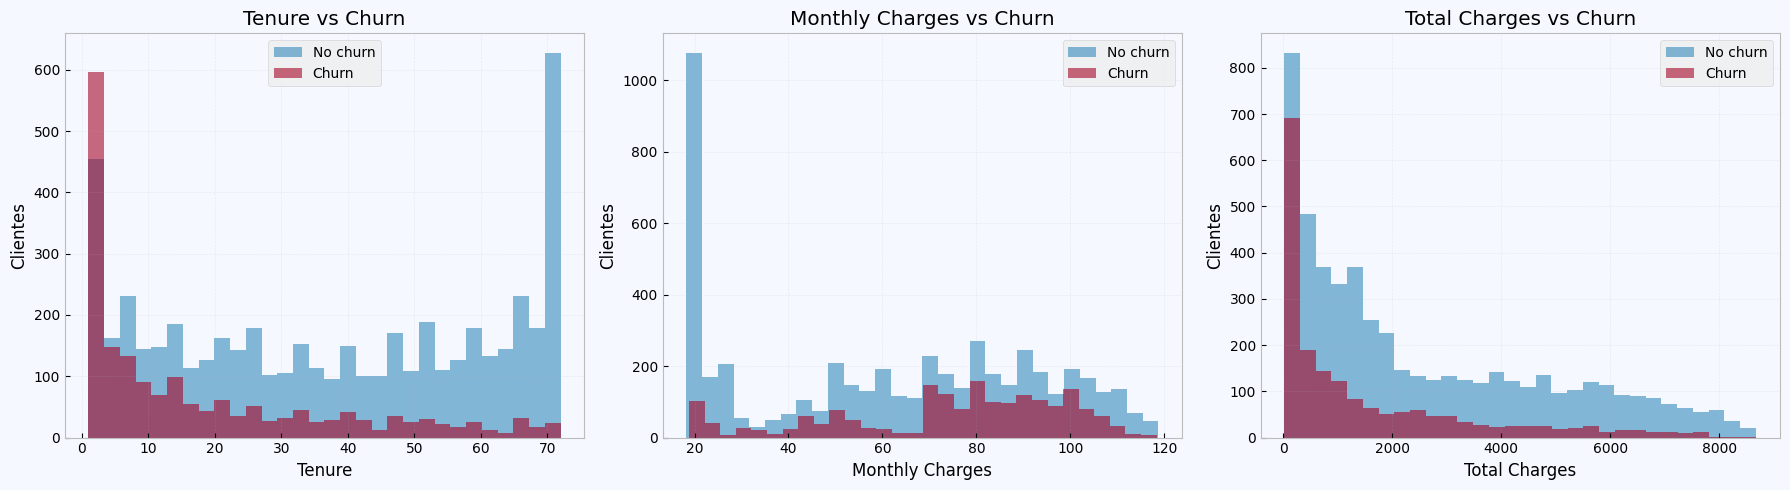

In [80]:
bg_color = "#f5f8ff"
churn_yes = df_churn[df_churn["churn"] == "Yes"]
churn_no = df_churn[df_churn["churn"] == "No"]
plt.figure(figsize=(18,5), facecolor=bg_color)

# Tenure
plt.subplot(1,3,1)
ax = plt.gca()
ax.set_facecolor(bg_color)
plt.hist(churn_no["tenure"], bins=30, alpha=0.6, label="No churn")
plt.hist(churn_yes["tenure"], bins=30, alpha=0.6, label="Churn")
plt.title("Tenure vs Churn")
plt.xlabel("Tenure")
plt.ylabel("Clientes")
plt.legend()
plt.grid(alpha=0.2)


# Monthly Charges
plt.subplot(1,3,2)
ax = plt.gca()
ax.set_facecolor(bg_color)
plt.hist(churn_no["monthlycharges"], bins=30, alpha=0.6, label="No churn")
plt.hist(churn_yes["monthlycharges"], bins=30, alpha=0.6, label="Churn")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Clientes")
plt.legend()
plt.grid(alpha=0.2)

# Total Charges
plt.subplot(1,3,3)
ax = plt.gca()
ax.set_facecolor(bg_color)
plt.hist(churn_no["totalcharges"], bins=30, alpha=0.6, label="No churn")
plt.hist(churn_yes["totalcharges"], bins=30, alpha=0.6, label="Churn")
plt.title("Total Charges vs Churn")
plt.xlabel("Total Charges")
plt.ylabel("Clientes")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [81]:
X = df_churn[["tenure","monthlycharges","totalcharges"]].dropna()
X["intercept"] = 1
vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

         variable        VIF
0          tenure   5.844646
1  monthlycharges   3.225293
2    totalcharges   9.526697
3       intercept  14.973839


In [82]:
df_churn = df_churn.drop(columns=["totalcharges"])

In [83]:
df_churn.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'churn'],
      dtype='object')

In [84]:
X = df_churn[["tenure","monthlycharges"]].dropna()
X["intercept"] = 1
vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

         variable       VIF
0          tenure  1.064896
1  monthlycharges  1.064896
2       intercept  6.302752


In [85]:
def churn_violin(y):
    bg_color = "#f5f8ff"
    plt.figure(figsize=(6,4), facecolor=bg_color)
    ax = plt.gca()
    ax.set_facecolor(bg_color)
    sns.violinplot(x="churn", y=y, data=df_churn)
    plt.title(f"{y.capitalize()} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(y.capitalize())
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

El gráfico muestra una relación negativa clara entre el tenure y la tasa de churn. A medida que aumenta la antigüedad del cliente, la probabilidad de abandono disminuye. La regresión lineal presenta un R² de 0.81, lo que indica una relación fuerte entre ambas variables y sugiere que el tiempo que un cliente lleva con la empresa es un factor importante para explicar el churn.

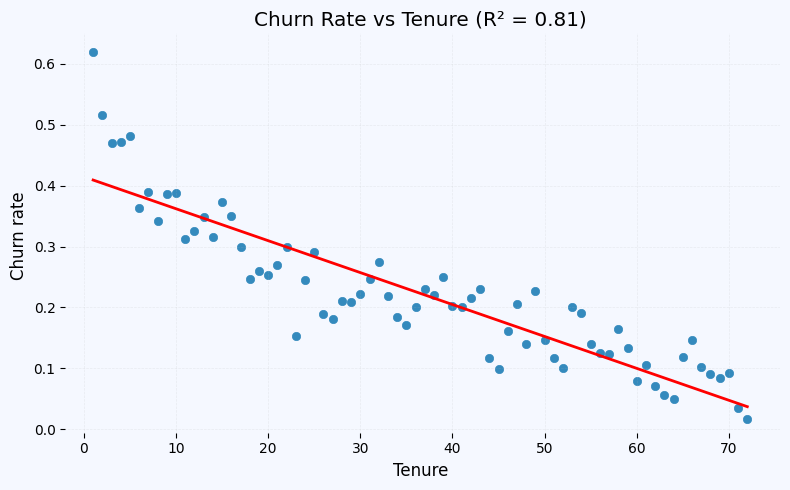

In [86]:
bg_color = "#f5f8ff"

tenure_churn = (
    df_churn
    .assign(churn_num=(df_churn["churn"] == "Yes").astype(int))
    .groupby("tenure")["churn_num"]
    .mean()
)

x = tenure_churn.index
y = tenure_churn.values

# regresión
m, b = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0,1]
r2 = r**2

# figura
plt.figure(figsize=(8,5), facecolor=bg_color)

ax = plt.gca()
ax.set_facecolor(bg_color)

# gráfico
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")

# títulos
plt.title(f"Churn Rate vs Tenure (R² = {r2:.2f})")
plt.xlabel("Tenure")
plt.ylabel("Churn rate")

# estética extra
for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

El gráfico muestra que los clientes que churnean tienden a tener monthly charges más altos que aquellos que permanecen en la empresa. Esto sugiere que los clientes con servicios más costosos presentan una mayor probabilidad de abandono. Esto podría indicar que los clientes con planes más costosos son más sensibles al valor percibido del servicio y, por lo tanto, tienen mayor probabilidad de abandonar si no se cumplen sus expectativas.

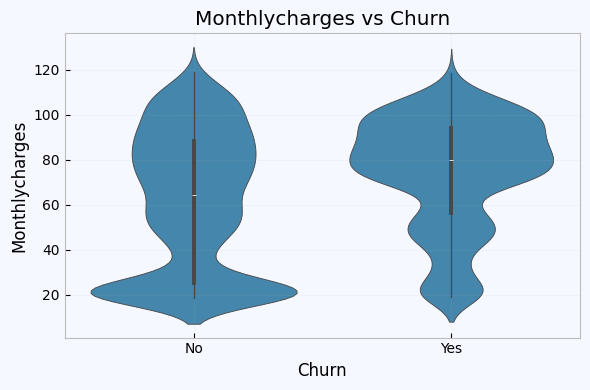

In [87]:
churn_violin("monthlycharges")

Transformamos las variables binarias para que sean 0/1 y poder realizar una correlación con el churn

In [88]:
binary_cols = [
    "partner",
    "dependents",
    "phoneservice",
    "paperlessbilling",
    "churn"
]

df_churn[binary_cols] = df_churn[binary_cols].replace({"Yes":1, "No":0})

/tmp/ipykernel_2028/636317191.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_churn[binary_cols] = df_churn[binary_cols].replace({"Yes":1, "No":0})


El gráfico muestra que no hay correlaciones muy fuertes con el churn en estas variables. La relación más visible es una correlación positiva leve con paperless billing (0.19), lo que sugiere que quienes usan facturación digital abandonan un poco más. En cambio, tener partner (-0.15) o dependents (-0.16) está levemente asociado con menor churn (familias).

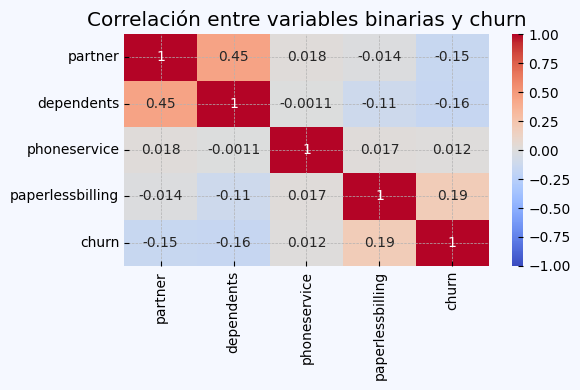

In [89]:
bg_color = "#f5f8ff"
corr_matrix = df_churn[binary_cols].corr()
plt.figure(figsize=(6,4), facecolor=bg_color)
ax = plt.gca()
ax.set_facecolor(bg_color)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=ax)

plt.title("Correlación entre variables binarias y churn")
plt.tight_layout()
plt.show()

# Encoding de datos

Como vimos antes, nuestras variables categóricas son: customerid, gender, partners, dependents, phoneservice, multiplelines, internetservice, onlinesecurity, onlinebackup, deviceprotection, techsupport, streamingtv, streamingmovies, contract, paperlessbilling, paymentmethod, totalcharges, churn. Por lo tanto, haremos el encoding de cada una de ellas para poder ser utilizadas posteriormente.

## Customerid

Eliminamos la columna customerid dado que consideramos no tiene importancia real sobre el churn del customer.

In [90]:
df_churn.drop(columns="customerid", inplace=True)

Probamos que se haya eliminado la columna customerid

In [91]:
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,1


## OHE

In [92]:
# seleccionar columnas categóricas
cat_cols = df_churn.select_dtypes(include="object").columns

# crear encoder
encoder = OneHotEncoder(drop="first", sparse_output=False)

# ajustar y transformar
encoded_array = encoder.fit_transform(df_churn[cat_cols])

# convertir a dataframe
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df_churn.index
)

# unir con variables numéricas
df_encoded = pd.concat(
    [df_churn.drop(columns=cat_cols), encoded_df],
    axis=1
)

In [93]:
df_encoded.head()

,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,churn,gender_Male,multiplelines_No phone service,...,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,1,0,1,0,1,29.85,0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0,0,34,1,0,56.95,0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0,0,0,2,1,1,53.85,1,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,0,45,0,0,42.30,0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,0,2,1,1,70.70,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [94]:
df_encoded.columns

Index(['seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice',
       'paperlessbilling', 'monthlycharges', 'churn', 'gender_Male',
       'multiplelines_No phone service', 'multiplelines_Yes',
       'internetservice_Fiber optic', 'internetservice_No',
       'onlinesecurity_No internet service', 'onlinesecurity_Yes',
       'onlinebackup_No internet service', 'onlinebackup_Yes',
       'deviceprotection_No internet service', 'deviceprotection_Yes',
       'techsupport_No internet service', 'techsupport_Yes',
       'streamingtv_No internet service', 'streamingtv_Yes',
       'streamingmovies_No internet service', 'streamingmovies_Yes',
       'contract_One year', 'contract_Two year',
       'paymentmethod_Credit card (automatic)',
       'paymentmethod_Electronic check', 'paymentmethod_Mailed check'],
      dtype='object')